# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [5]:
from PIL import Image, ImageOps
import numpy as np
from IPython.display import display


Image size: (685, 685)


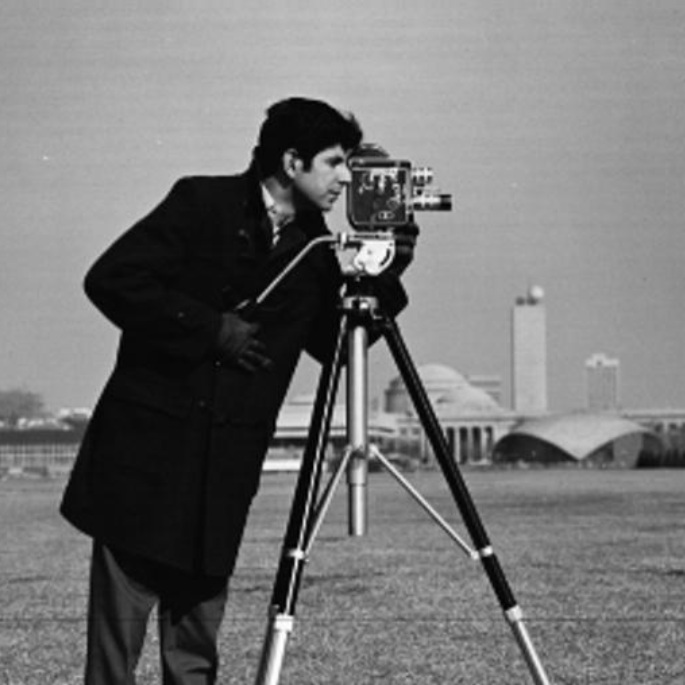

In [8]:
img = Image.open(r"C:\Users\miada\OneDrive\Desktop\lab3\lab3_input.jpg").convert("RGB")

print("Image size:", img.size)
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [9]:
width, height = img.size

cx = 2
cy = 2

print("Original width:", width)
print("Original height:", height)

Original width: 685
Original height: 685


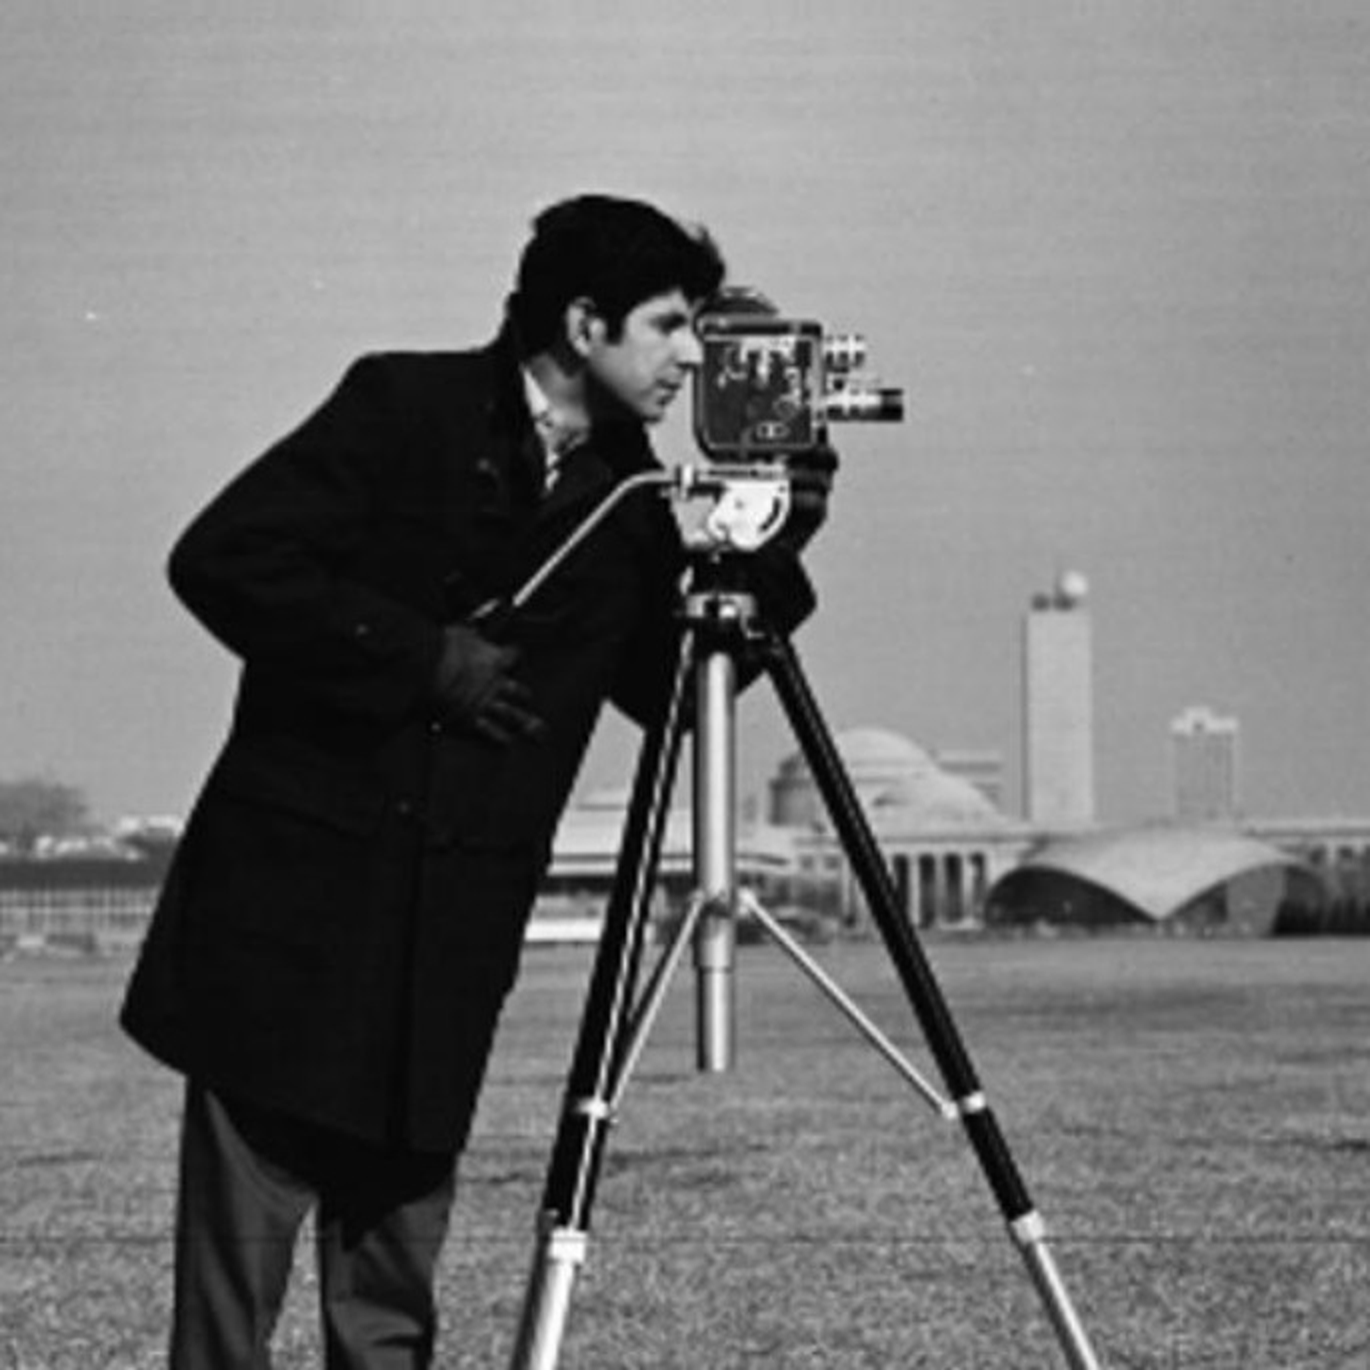

In [10]:
new_width = width * cx
new_height = height * cy

scaled_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

display(scaled_img)


In [11]:
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (685, 685)
Scaled size: (1370, 1370)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [12]:
cx = 2
cy = 1

new_width = width * cx
new_height = height * cy

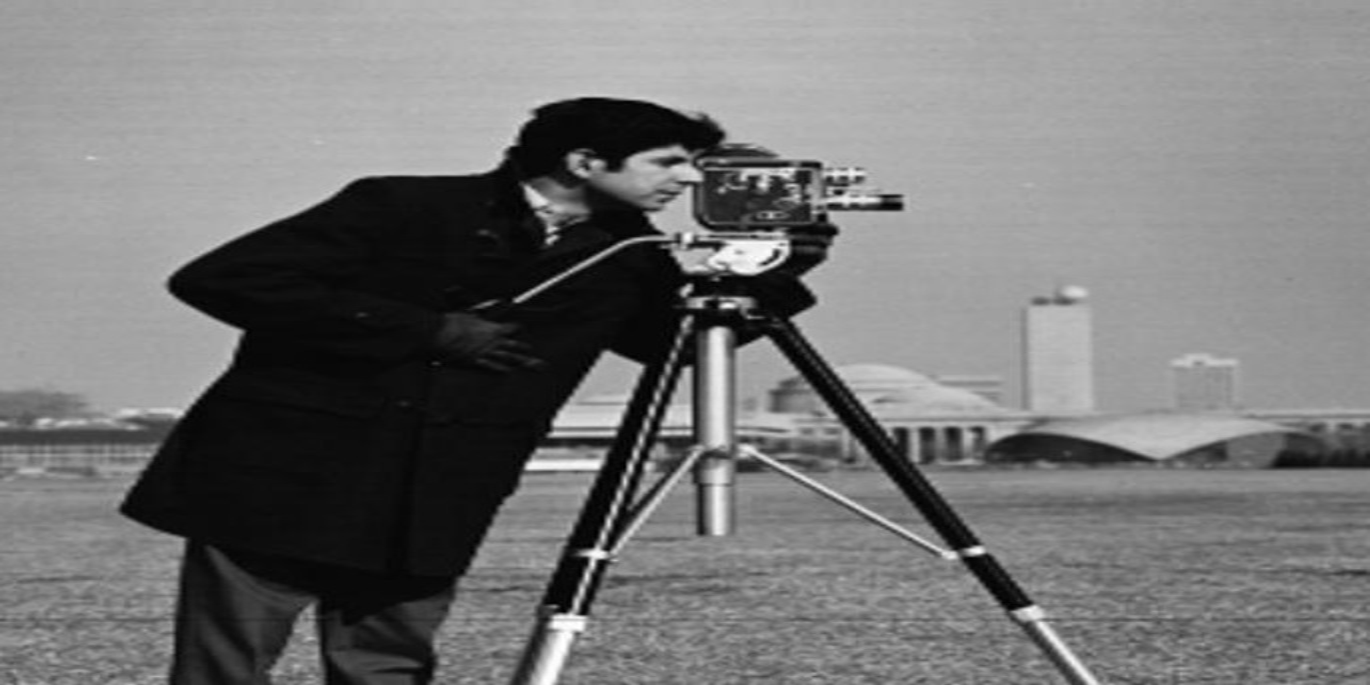

In [13]:
horizontal_stretch = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)

display(horizontal_stretch)

In [14]:
horizontal_stretch.save("task1_non_uniform_scaled.jpg")

print("Original size:", img.size)
print("New size:", horizontal_stretch.size)

Original size: (685, 685)
New size: (1370, 685)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (685, 685)
Rotated size: (937, 937)


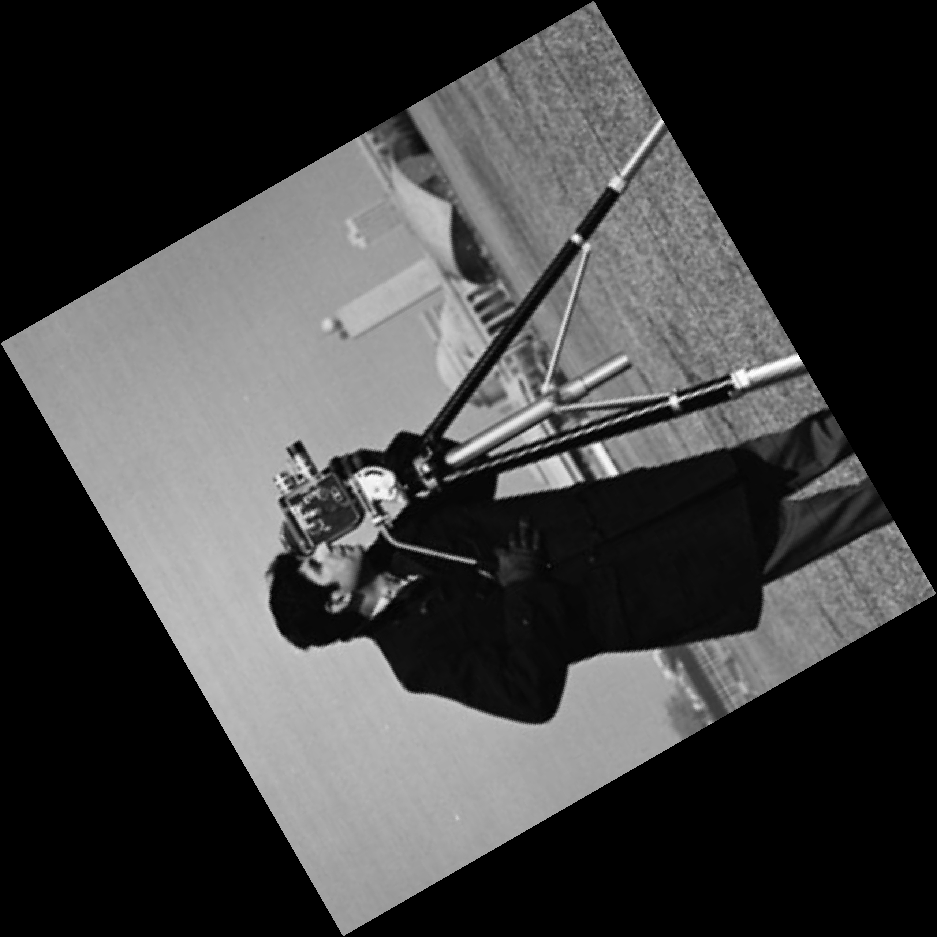

In [15]:
rotated_img = img.rotate(120, expand=True)

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)
display(rotated_img)

### 3. Shear

In [16]:
width, height = img.size

print("Width:", width)
print("Height:", height)


Width: 685
Height: 685


In [17]:
shx = 0.5

new_width = int(width + abs(shx) * height)
new_height = height

print("Shear factor:", shx)
print("New canvas size:", (new_width, new_height))

Shear factor: 0.5
New canvas size: (1027, 685)


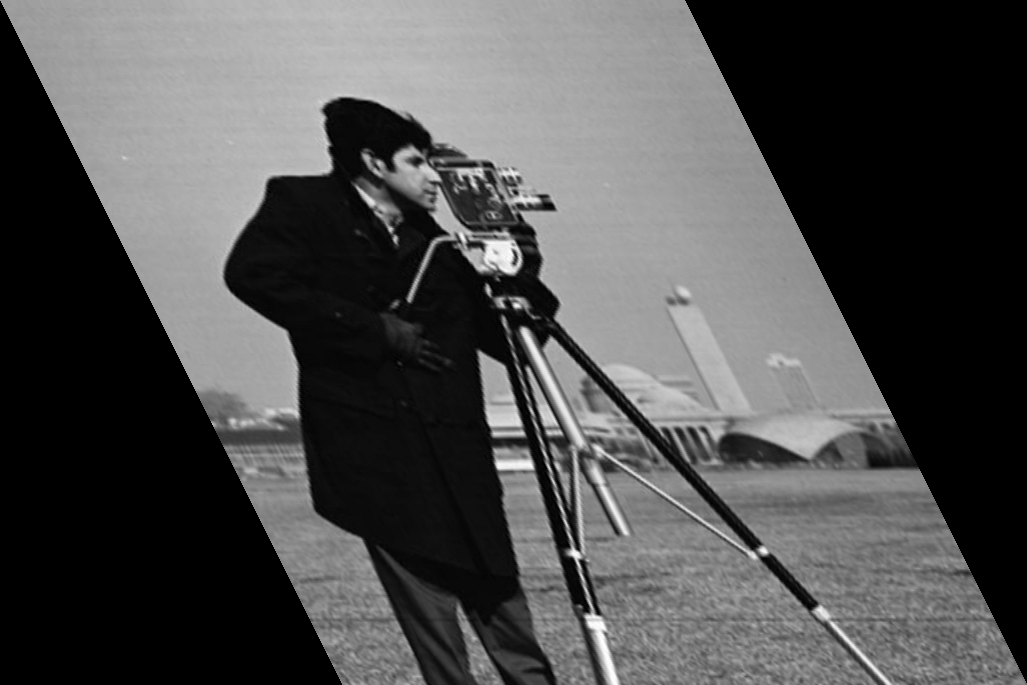

In [19]:
sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

display(sheared_img)

In [20]:
sheared_img.save("task1_3_sheared.jpg")

print("Saved as task1_3_sheared.jpg")

Saved as task1_3_sheared.jpg


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

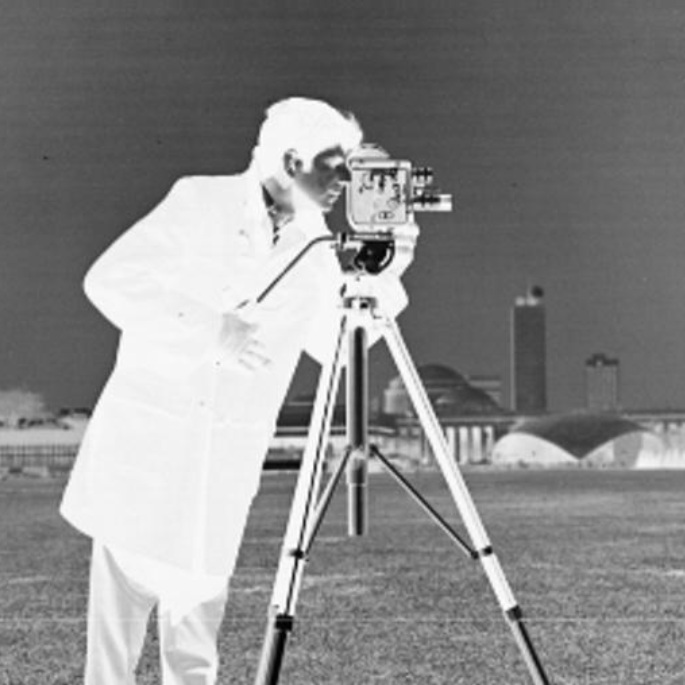

In [21]:
arr = np.array(img)

negative_arr = 255 - arr
negative_img = Image.fromarray(negative_arr.astype(np.uint8))

negative_img.save("task2_1_negative_numpy.jpg")
display(negative_img)


In [ ]:
# Method 2: PIL's ImageOps


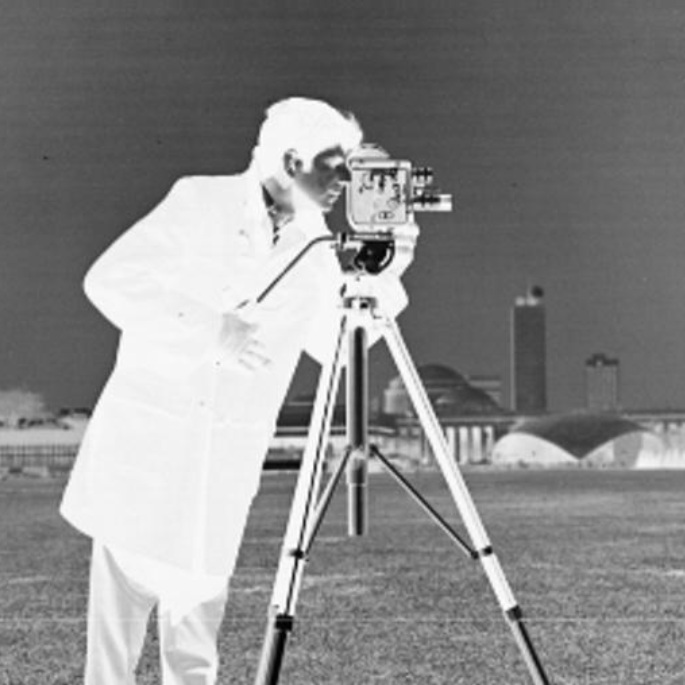

In [22]:
negative_pil = ImageOps.invert(img.convert("RGB"))

negative_pil.save("task2_1_negative_pil.jpg")
display(negative_pil)


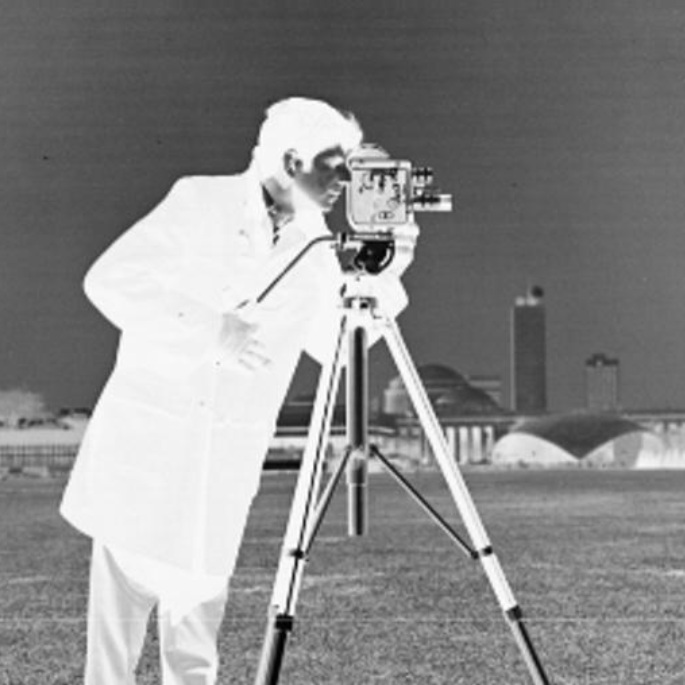

In [23]:

negative_pil = ImageOps.invert(img.convert("RGB"))

negative_pil.save("task2_1_negative_pil.jpg")
display(negative_pil)

c = 45.98590442833571


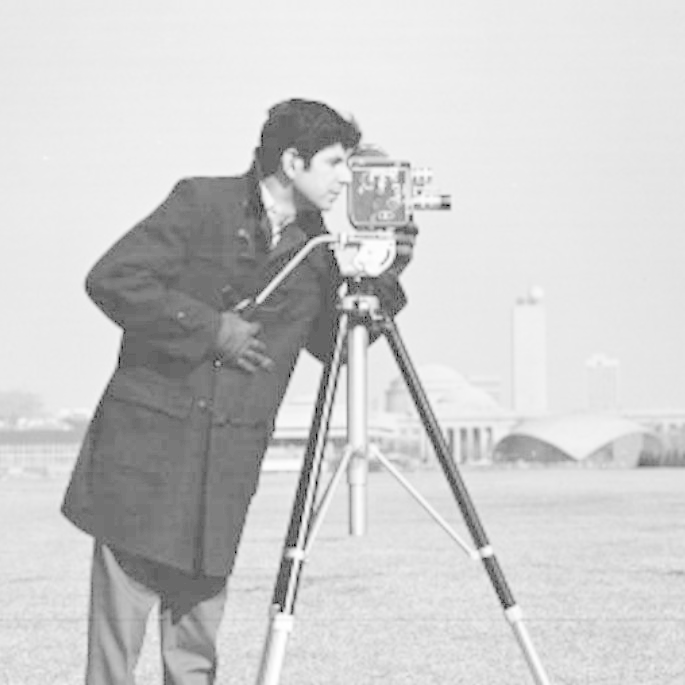

In [24]:
arr = np.array(img).astype(np.float32)

c = 255 / np.log(1 + 255)
log_arr = c * np.log(1 + arr)

log_arr = np.clip(log_arr, 0, 255).astype(np.uint8)
log_img = Image.fromarray(log_arr)

log_img.save("task2_2_log.jpg")

print("c =", c)
display(log_img)

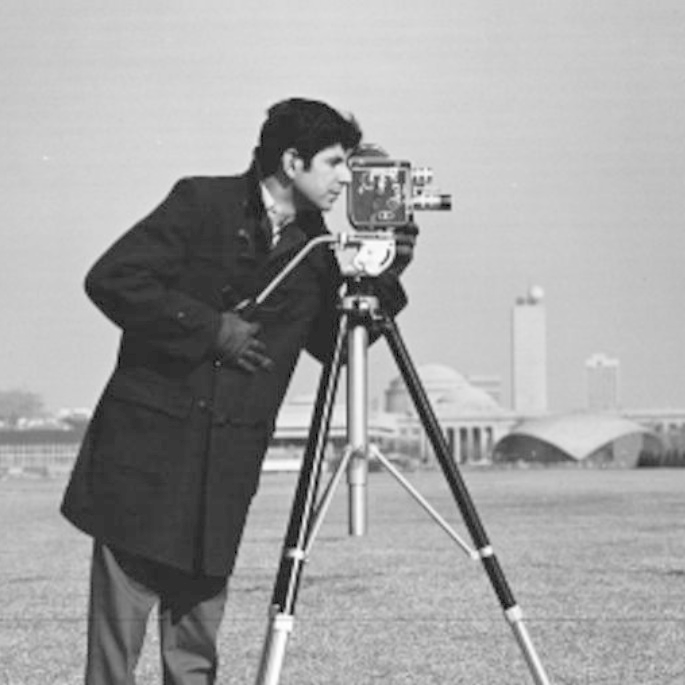

In [25]:
gamma = 0.5

arr = np.array(img).astype(np.float32)
normalized = arr / 255.0

gamma_arr = 255 * (normalized ** gamma)
gamma_arr = np.clip(gamma_arr, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_arr)
display(gamma_img)

In [26]:
gamma_img.save("task2_3_gamma.jpg")

print("Gamma value:", gamma)
print("Saved as task2_3_gamma.jpg")

Gamma value: 0.5
Saved as task2_3_gamma.jpg


Shear factor: 0.1


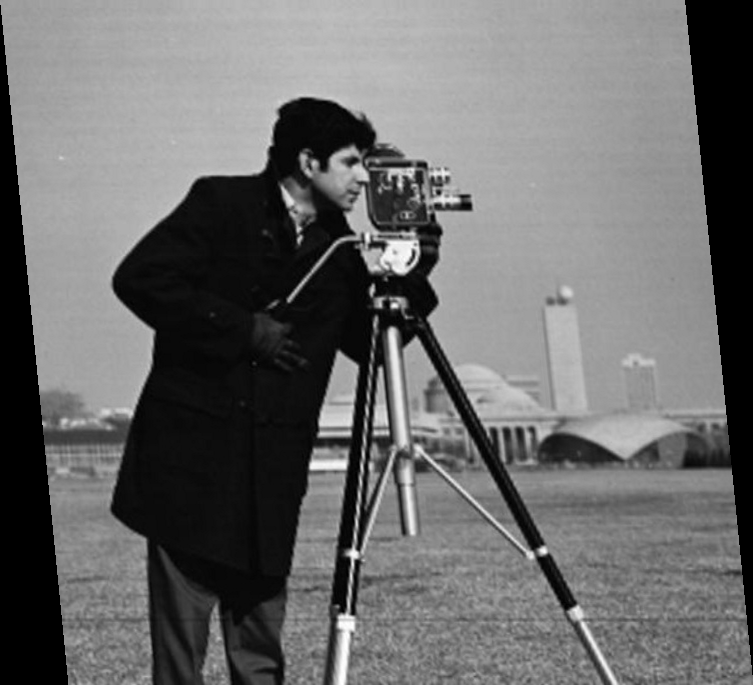

Shear factor: 0.3


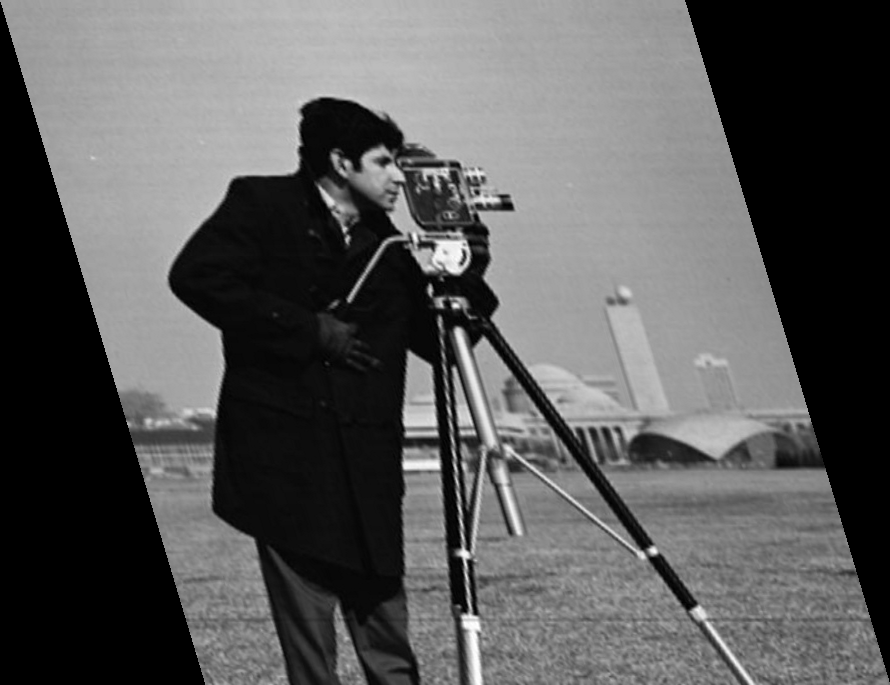

Shear factor: 0.8


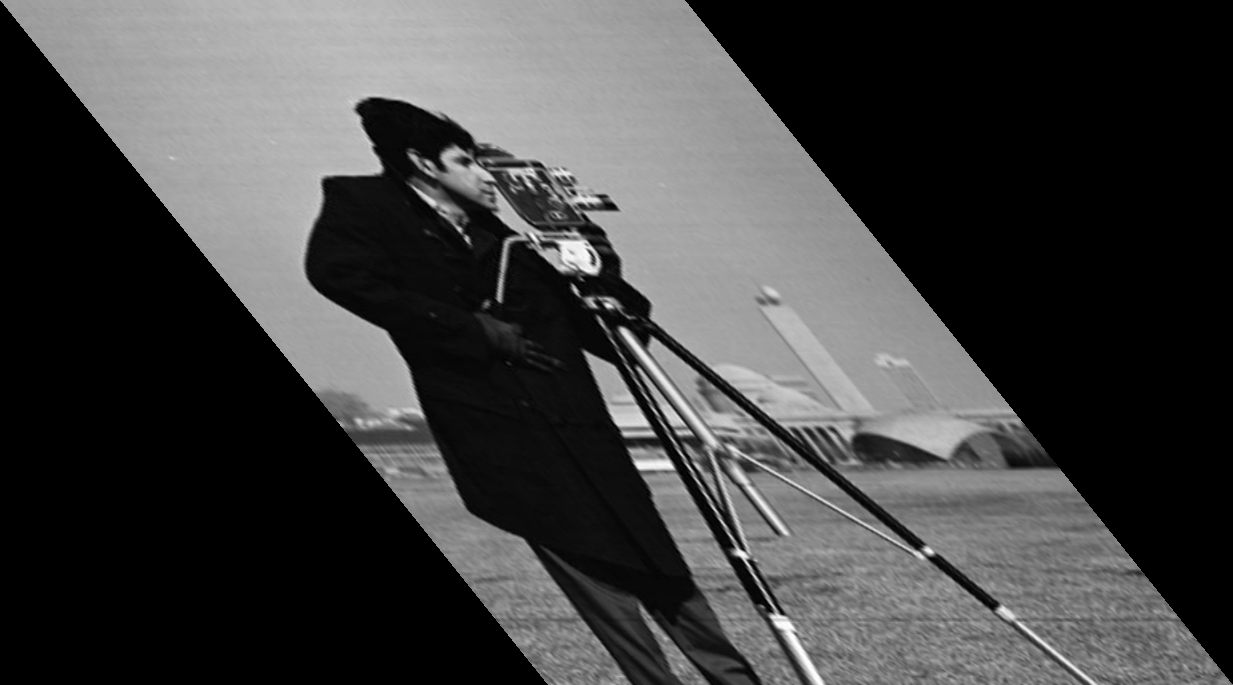

In [27]:
width, height = img.size

for shx in [0.1, 0.3, 0.8]:
    new_width = int(width + abs(shx) * height)

    result = img.transform(
        (new_width, height),
        Image.Transform.AFFINE,
        (1, -shx, 0, 0, 1, 0),
        resample=Image.Resampling.BICUBIC
    )

    print("Shear factor:", shx)
    display(result)
    result.save(f"shear_x_{shx}.jpg")

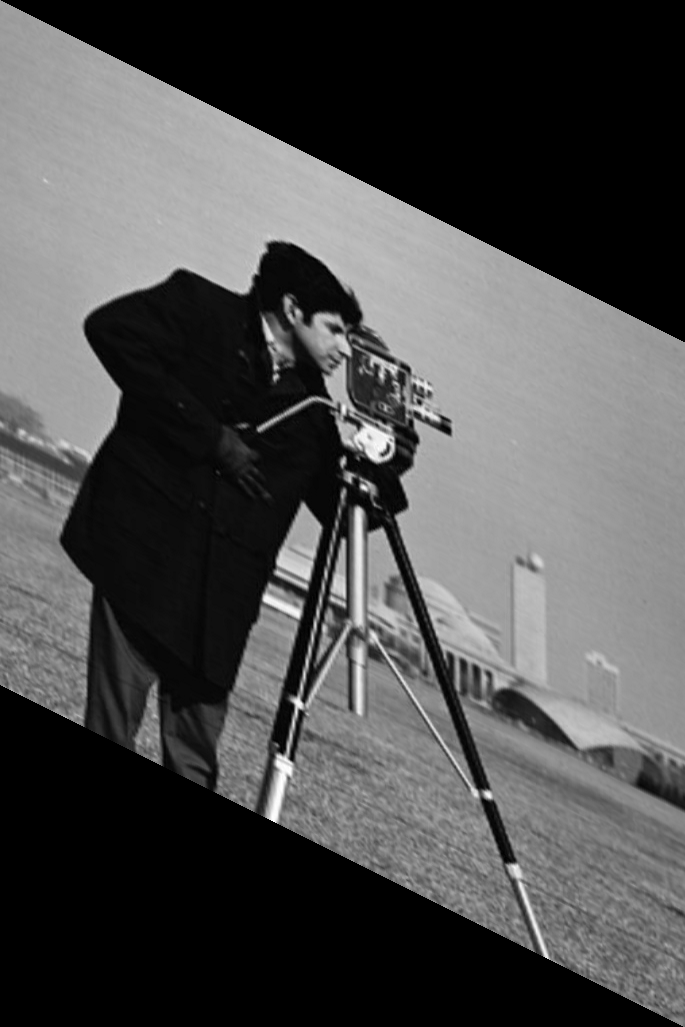

In [28]:
width, height = img.size
shy = 0.5

new_height = int(height + abs(shy) * width)

y_sheared = img.transform(
    (width, new_height),
    Image.Transform.AFFINE,
    (1, 0, 0, -shy, 1, 0),
    resample=Image.Resampling.BICUBIC
)

display(y_sheared)
y_sheared.save("shear_y_0.5.jpg")

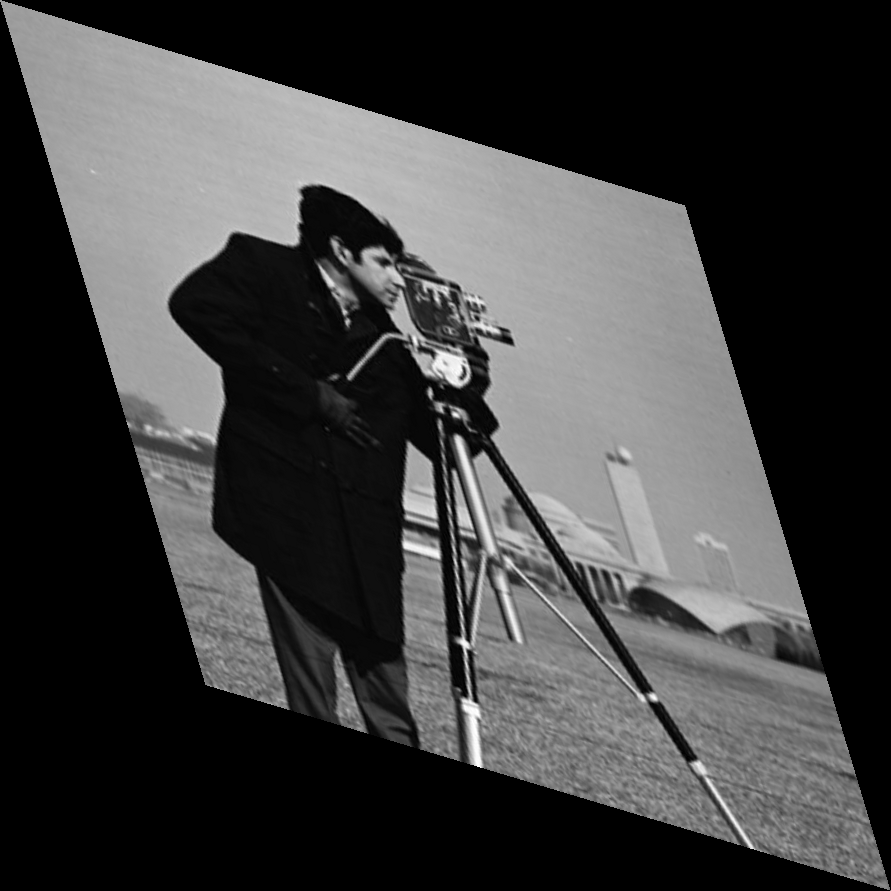

In [29]:
width, height = img.size

shx = 0.3
shy = 0.3

new_width = int(np.ceil(width + shx * height))
new_height = int(np.ceil(height + shy * width))

d = 1 - shx * shy

combined_shear = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1 / d, -shx / d, 0, -shy / d, 1 / d, 0),
    resample=Image.Resampling.BICUBIC
)

display(combined_shear)
combined_shear.save("shear_combined.jpg")

In [30]:
import os
print(os.getcwd())

C:\Users\miada
